# Clínica de Diagnóstico de Negocio
## Predicción de abandono de clientes con datos simulados

**Caso de negocio:** anticipar qué clientes tienen mayor riesgo de abandonar un servicio de suscripción para priorizar acciones de retención.

**Integrantes:** Completar con los nombres del equipo  
**Fecha:** Completar antes de entregar

---

### Origen y límite de los datos

El archivo `Churn Prediction.csv` contiene únicamente `id` y `Exited`. Los valores de `Exited` están entre 0 y 1 y se tratan aquí como **puntuaciones de predicción**. El archivo no incluye una etiqueta histórica binaria de abandono ni variables explicativas; por ello no permite entrenar y evaluar modelos supervisados por sí solo.

Se simula un conjunto de clientes para poder comparar modelos supervisados. La media de `Exited` se usa **solo como supuesto numérico** para fijar la tasa objetivo de abandono de la simulación; no se interpreta como tasa observada ni como probabilidad calibrada. Las variables y etiquetas posteriores son sintéticas. Las métricas obtenidas describen el desempeño dentro de esta simulación y no estiman el desempeño con clientes reales.


## 1. Descripción del problema de negocio

En el Caso A, el negocio necesita identificar clientes que podrían abandonar su relación con la empresa. Se supone un **servicio de suscripción**: cada cliente puede permanecer o cancelar, y el equipo de retención tiene recursos limitados para intervenir.

La variable objetivo **Y = `Churn`** es categórica binaria: `1` indica abandono y `0` permanencia. El modelo emplea señales disponibles antes de la decisión, como frecuencia de uso, gasto, tiempo desde la última interacción, llamadas a soporte, retrasos de pago y tipo de contrato. Estas variables representan actividad y soporte propios de una suscripción.

Con las predicciones, la empresa podría priorizar contactos de retención y revisar problemas de soporte o pago. El éxito operativo se mediría por los abandonos detectados, las intervenciones innecesarias y el costo de la campaña. En este notebook la etiqueta y los clientes son **simulados**, por lo que la recomendación final sirve para comparar algoritmos en el ejercicio, no para decidir sobre personas reales.


In [1]:
import sys
import subprocess
from importlib.util import find_spec

# Instala solo las dependencias que falten en el mismo entorno del kernel de Jupyter.
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}
missing_packages = [package for module, package in required_packages.items() if find_spec(module) is None]
if missing_packages:
    print("Instalando dependencias faltantes:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42
rng = np.random.default_rng(SEED)


## 2. Validación del archivo suministrado y construcción del dataset

`Churn Prediction.csv` se revisa primero para decidir si sirve como dataset supervisado. Contiene 110,023 identificadores y puntuaciones `Exited`, pero no incluye variables explicativas ni etiquetas observadas de abandono. Por eso se usa **solo la media de sus puntuaciones (21.30%) como supuesto didáctico** para fijar el riesgo medio esperado en la simulación. Esa media no demuestra la tasa real de abandono ni la calibración de las puntuaciones.

Se generan **8,000 clientes enteramente sintéticos**, con IDs nuevos que no corresponden a las filas de `Churn Prediction.csv`. Las variables representan un servicio de suscripción hipotético; sus rangos y relaciones son supuestos del ejercicio, no propiedades verificadas de una empresa. La etiqueta `Churn` se sortea a partir de una probabilidad calculada con actividad, soporte, pagos y contrato. La tasa observada en la muestra puede diferir ligeramente del 21.30% objetivo por el azar del sorteo.

| Variable simulada | Interpretación en el caso |
| --- | --- |
| `tenure` | Meses como cliente (1 a 60). |
| `usage_frequency` | Usos del servicio en un periodo de 30 días (1 a 30). |
| `support_calls` | Llamadas de soporte en ese periodo (0 a 12). |
| `payment_delay` | Días de retraso en el pago (0 a 30). |
| `last_interaction` | Días desde la última interacción (1 a 30). |
| `total_spend` | Gasto acumulado en unidades monetarias ficticias. |
| `subscription_type`, `contract_length` | Plan y duración contractual. |
| `age`, `gender` | Datos sintéticos usados solo en la auditoría descriptiva por grupos; no entran en los modelos. |
| `language`, `pet` | Datos sintéticos excluidos del entrenamiento y de la auditoría por falta de justificación en el caso. |

Este dataset representa **el escenario hipotético definido aquí**. Su representatividad frente a clientes reales no puede comprobarse con `Churn Prediction.csv`.


In [2]:
DATA_PATH = Path("Churn Prediction.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró Churn Prediction.csv. Ejecute el notebook desde la carpeta que contiene el archivo."
    )

submission = pd.read_csv(DATA_PATH)
if list(submission.columns) != ["id", "Exited"]:
    raise ValueError(f"Se esperaban las columnas id y Exited; se encontraron {submission.columns.tolist()}.")
if submission.empty or submission["id"].isna().any() or submission["id"].duplicated().any():
    raise ValueError("El archivo debe contener identificadores únicos y no vacíos.")
if not pd.api.types.is_numeric_dtype(submission["Exited"]):
    raise TypeError("Exited debe ser una puntuación numérica.")
if submission["Exited"].isna().any() or not np.isfinite(submission["Exited"].to_numpy()).all():
    raise ValueError("Exited debe contener puntuaciones finitas y completas.")
if not submission["Exited"].between(0, 1).all():
    raise ValueError("Exited debe estar dentro del intervalo [0, 1].")

submission_profile = pd.DataFrame({
    "métrica": [
        "registros", "columnas", "IDs duplicados", "nulos", "valores binarios de Exited",
        "mínimo Exited", "media Exited", "máximo Exited",
    ],
    "valor": [
        len(submission), len(submission.columns), int(submission["id"].duplicated().sum()),
        int(submission.isna().sum().sum()), int(submission["Exited"].isin([0, 1]).sum()),
        submission["Exited"].min(), submission["Exited"].mean(), submission["Exited"].max(),
    ],
})
display(submission_profile)

target_rate = float(submission["Exited"].mean())
if not 0 < target_rate < 1:
    raise ValueError("La media de Exited debe estar entre 0 y 1 para calibrar la simulación.")
print("Aptitud para aprendizaje supervisado: insuficiente (faltan X y una Y observada).")
print(f"Tasa objetivo asumida para la simulación (media de Exited): {target_rate:.2%}")


,métrica,valor
0,registros,110023.000000
1,columnas,2.000000
2,IDs duplicados,0.000000
3,nulos,0.000000
4,valores binarios de Exited,0.000000
5,mínimo Exited,0.000462
6,media Exited,0.212977
7,máximo Exited,0.996254


Aptitud para aprendizaje supervisado: insuficiente (faltan X y una Y observada).
Tasa objetivo asumida para la simulación (media de Exited): 21.30%


In [3]:
# Generación reproducible de un escenario hipotético con IDs nuevos.
N_CLIENTES = 8_000
if N_CLIENTES < 200:
    raise ValueError("La simulación requiere al menos 200 registros.")
synthetic_ids = np.array([f"SIM-{i:05d}" for i in range(1, N_CLIENTES + 1)])

age = np.clip(np.rint(rng.normal(40, 11, N_CLIENTES)), 18, 75).astype(int)
gender = rng.choice(["Female", "Male", "Non-binary"], size=N_CLIENTES, p=[0.48, 0.48, 0.04])
tenure = rng.integers(1, 61, size=N_CLIENTES)
usage_frequency = rng.integers(1, 31, size=N_CLIENTES)
support_calls = np.clip(rng.poisson(3.0, N_CLIENTES), 0, 12)
payment_delay = rng.integers(0, 31, size=N_CLIENTES)
last_interaction = rng.integers(1, 31, size=N_CLIENTES)
subscription_type = rng.choice(["Basic", "Standard", "Premium"], size=N_CLIENTES, p=[0.34, 0.42, 0.24])
contract_length = rng.choice(["Monthly", "Quarterly", "Annual"], size=N_CLIENTES, p=[0.34, 0.28, 0.38])
language = rng.choice(["Spanish", "English", "German", "Other"], size=N_CLIENTES)
pet = rng.choice(["No pet", "Dog", "Cat", "Other"], size=N_CLIENTES)

# El gasto se relaciona con uso y antigüedad, con variación individual.
total_spend = np.clip(
    130 + 7.8 * tenure + 12.0 * usage_frequency + rng.normal(0, 115, N_CLIENTES),
    80,
    1_800,
).round(2)

# Riesgo latente: se usan únicamente conductas y condiciones contractuales.
# Edad, género, idioma y mascota no causan el riesgo ni se incluirán en el modelo.
subscription_effect = np.select(
    [subscription_type == "Basic", subscription_type == "Premium"], [0.25, -0.15], default=0.0
)
contract_effect = np.select(
    [contract_length == "Monthly", contract_length == "Annual"], [0.40, -0.35], default=0.0
)
behavioral_score = (
    0.48 * support_calls + 0.075 * payment_delay - 0.027 * tenure
    - 0.040 * usage_frequency + 0.035 * last_interaction
    - 0.00065 * total_spend + subscription_effect + contract_effect
)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Se calibra el intercepto por bisección para mantener la tasa media del archivo base.
low, high = -12.0, 12.0
for _ in range(80):
    midpoint = (low + high) / 2
    if sigmoid(midpoint + behavioral_score).mean() < target_rate:
        low = midpoint
    else:
        high = midpoint
churn_probability = sigmoid((low + high) / 2 + behavioral_score)
churn = rng.binomial(1, churn_probability)

churn_df = pd.DataFrame({
    "customer_id": synthetic_ids,
    "age": age,
    "gender": gender,
    "tenure": tenure,
    "usage_frequency": usage_frequency,
    "support_calls": support_calls,
    "payment_delay": payment_delay,
    "subscription_type": subscription_type,
    "contract_length": contract_length,
    "total_spend": total_spend,
    "last_interaction": last_interaction,
    "language": language,
    "pet": pet,
    "Churn": churn,
})

assert churn_df["customer_id"].is_unique
assert set(churn_df["Churn"].unique()) == {0, 1}
print(f"Registros simulados: {len(churn_df):,}")
assert np.isclose(churn_probability.mean(), target_rate, atol=1e-10)
print(f"Probabilidad media calibrada antes del sorteo: {churn_probability.mean():.2%}")
print(f"Tasa de abandono simulada: {churn_df['Churn'].mean():.2%}")
print(f"Diferencia respecto del supuesto (puntos porcentuales): {(churn_df['Churn'].mean() - target_rate) * 100:+.2f}")
display(churn_df.head())


Registros simulados: 8,000
Probabilidad media calibrada antes del sorteo: 21.30%
Tasa de abandono simulada: 21.77%
Diferencia respecto del supuesto (puntos porcentuales): +0.48


,customer_id,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,language,pet,Churn
0,SIM-00001,43,Male,45,7,3,21,Basic,Annual,561.60,16,Other,Cat,1
1,SIM-00002,29,Male,35,22,3,15,Basic,Annual,811.39,11,German,No pet,0
2,SIM-00003,48,Female,20,19,1,30,Basic,Annual,557.21,4,Spanish,Dog,0
3,SIM-00004,50,Female,34,13,4,3,Standard,Quarterly,543.65,3,English,No pet,1
4,SIM-00005,19,Female,9,2,3,22,Standard,Annual,302.56,9,English,Dog,0


## 3. Exploración de datos (EDA)

La exploración usa `matplotlib` y `seaborn` para examinar el conjunto simulado. Esta sección comprueba cantidad y calidad de registros, describe las variables numéricas y muestra el balance de la etiqueta `Churn`. Después compara retrasos de pago y duración contractual con el abandono. Las asociaciones reflejan **las reglas de la simulación**; no describen clientes reales ni prueban causalidad.


,indicador,valor
0,Clientes simulados,8000
1,Columnas,14
2,Valores faltantes,0
3,IDs duplicados,0
4,Filas repetidas sin ID,0
5,Tasa de abandono,21.77%


Resumen de variables numéricas (datos simulados):


,count,mean,std,min,25%,50%,75%,max
tenure,8000.0,30.45,17.42,1.0,15.00,31.00,45.00,60.00
usage_frequency,8000.0,15.55,8.67,1.0,8.00,16.00,23.00,30.00
support_calls,8000.0,3.01,1.74,0.0,2.00,3.00,4.00,11.00
payment_delay,8000.0,15.11,8.96,0.0,7.00,15.00,23.00,30.00
total_spend,8000.0,553.33,207.51,80.0,405.16,552.58,700.34,1213.09
last_interaction,8000.0,15.55,8.59,1.0,8.00,16.00,23.00,30.00


Balance de la variable objetivo:


,resultado,clientes,porcentaje
0,Permanece,6258,0.7822
1,Abandona,1742,0.2178


Abandono por duración de contrato:


,contrato,clientes,tasa_abandono
0,Anual,3072,0.1758
1,Trimestral,2260,0.2119
2,Mensual,2668,0.2710


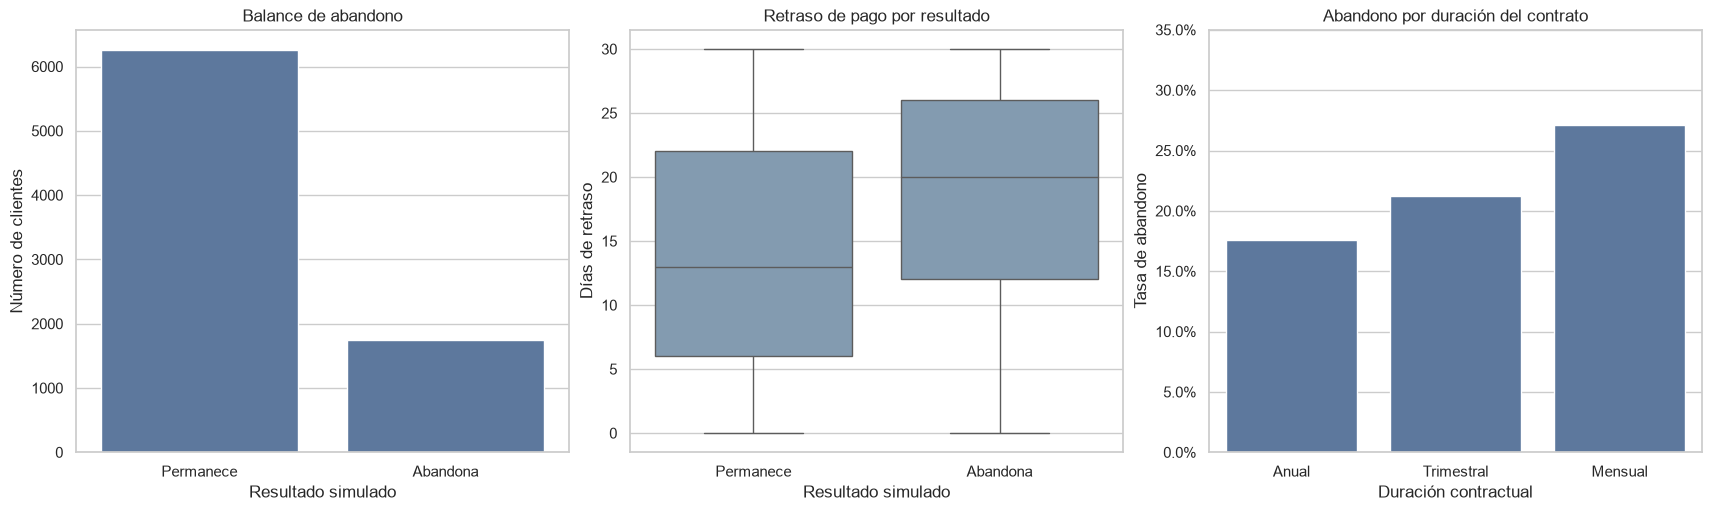

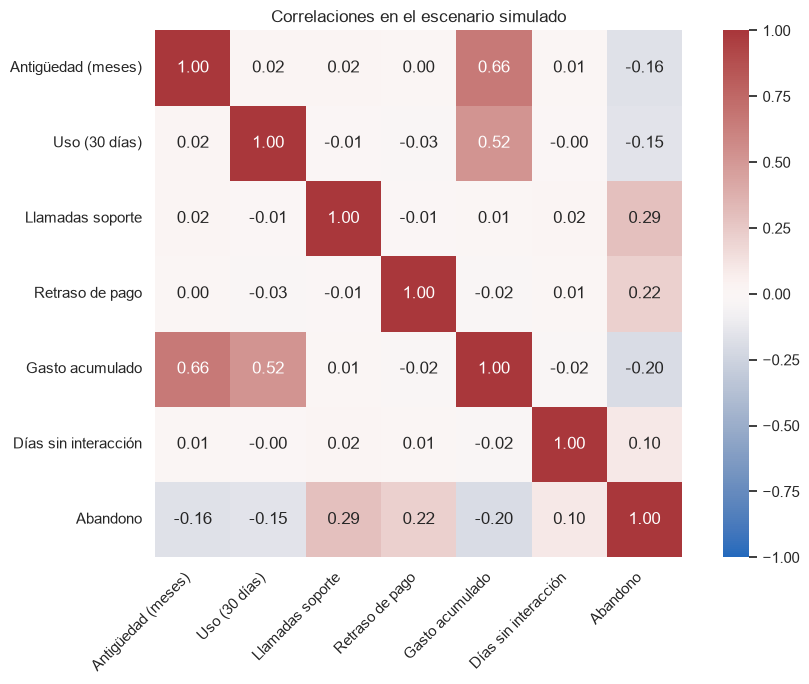


**Lectura del EDA.** Abandonó el **21.8%** de los clientes simulados. Entre quienes abandonaron, la mediana del retraso de pago fue **20 días**, frente a **13 días** entre quienes permanecieron; la mediana de llamadas a soporte fue **4** frente a **3**. La tasa de abandono fue **27.1%** en contratos mensuales y **17.6%** en anuales.

Estas diferencias son esperables por las reglas usadas para generar `Churn`. No se deben interpretar como evidencia observacional ni como efectos causales de pagos, soporte o contrato.


In [4]:
from matplotlib.ticker import PercentFormatter

# Calidad y estructura del dataset sintético.
rows_without_id = churn_df.drop(columns="customer_id")
quality_summary = pd.DataFrame({
    "indicador": [
        "Clientes simulados", "Columnas", "Valores faltantes",
        "IDs duplicados", "Filas repetidas sin ID", "Tasa de abandono",
    ],
    "valor": [
        len(churn_df), len(churn_df.columns), int(churn_df.isna().sum().sum()),
        int(churn_df["customer_id"].duplicated().sum()),
        int(rows_without_id.duplicated().sum()), f"{churn_df['Churn'].mean():.2%}",
    ],
})
display(quality_summary)

eda_numeric = [
    "tenure", "usage_frequency", "support_calls", "payment_delay",
    "total_spend", "last_interaction",
]
print("Resumen de variables numéricas (datos simulados):")
display(churn_df[eda_numeric].describe().T.round(2))

class_balance = (
    churn_df["Churn"].value_counts().sort_index()
    .rename_axis("Churn").reset_index(name="clientes")
)
class_balance["resultado"] = class_balance["Churn"].map({0: "Permanece", 1: "Abandona"})
class_balance["porcentaje"] = class_balance["clientes"] / len(churn_df)
print("Balance de la variable objetivo:")
display(class_balance[["resultado", "clientes", "porcentaje"]].round({"porcentaje": 4}))

contract_order = ["Annual", "Quarterly", "Monthly"]
contract_summary = (
    churn_df.groupby("contract_length")["Churn"]
    .agg(clientes="size", tasa_abandono="mean")
    .reindex(contract_order).reset_index()
)
contract_summary["contrato"] = contract_summary["contract_length"].map({
    "Annual": "Anual", "Quarterly": "Trimestral", "Monthly": "Mensual",
})
print("Abandono por duración de contrato:")
display(contract_summary[["contrato", "clientes", "tasa_abandono"]].round({"tasa_abandono": 4}))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
sns.countplot(data=churn_df, x="Churn", order=[0, 1], ax=axes[0], color="#5277a8")
axes[0].set_title("Balance de abandono")
axes[0].set_xlabel("Resultado simulado")
axes[0].set_ylabel("Número de clientes")
axes[0].set_xticks([0, 1], labels=["Permanece", "Abandona"])

sns.boxplot(data=churn_df, x="Churn", y="payment_delay", order=[0, 1], ax=axes[1], color="#7b9bb8")
axes[1].set_title("Retraso de pago por resultado")
axes[1].set_xlabel("Resultado simulado")
axes[1].set_ylabel("Días de retraso")
axes[1].set_xticks([0, 1], labels=["Permanece", "Abandona"])

sns.barplot(data=contract_summary, x="contrato", y="tasa_abandono", ax=axes[2], color="#5277a8")
axes[2].set_title("Abandono por duración del contrato")
axes[2].set_xlabel("Duración contractual")
axes[2].set_ylabel("Tasa de abandono")
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].set_ylim(0, max(0.35, contract_summary["tasa_abandono"].max() * 1.15))
plt.show()

labels_es = {
    "tenure": "Antigüedad (meses)",
    "usage_frequency": "Uso (30 días)",
    "support_calls": "Llamadas soporte",
    "payment_delay": "Retraso de pago",
    "total_spend": "Gasto acumulado",
    "last_interaction": "Días sin interacción",
    "Churn": "Abandono",
}
corr = churn_df[eda_numeric + ["Churn"]].rename(columns=labels_es).corr()
plt.figure(figsize=(9.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlaciones en el escenario simulado")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

median_delay = churn_df.groupby("Churn")["payment_delay"].median()
median_calls = churn_df.groupby("Churn")["support_calls"].median()
annual_rate = contract_summary.loc[contract_summary["contract_length"] == "Annual", "tasa_abandono"].iloc[0]
monthly_rate = contract_summary.loc[contract_summary["contract_length"] == "Monthly", "tasa_abandono"].iloc[0]
display(Markdown(
    f"""
**Lectura del EDA.** Abandonó el **{churn_df['Churn'].mean():.1%}** de los clientes simulados. Entre quienes abandonaron, la mediana del retraso de pago fue **{median_delay[1]:.0f} días**, frente a **{median_delay[0]:.0f} días** entre quienes permanecieron; la mediana de llamadas a soporte fue **{median_calls[1]:.0f}** frente a **{median_calls[0]:.0f}**. La tasa de abandono fue **{monthly_rate:.1%}** en contratos mensuales y **{annual_rate:.1%}** en anuales.

Estas diferencias son esperables por las reglas usadas para generar `Churn`. No se deben interpretar como evidencia observacional ni como efectos causales de pagos, soporte o contrato.
"""
))


## 4. Mapa de selección de algoritmos

1. **Tipo de objetivo.** `Churn` toma los valores 0 (permanece) y 1 (abandona). Es una variable categórica binaria; corresponde usar **clasificación supervisada**, no regresión de un valor continuo.
2. **Objetivo estratégico.** Se quiere priorizar acciones de retención. Se supone que omitir a un cliente que abandona es costoso, pero también lo es contactar a muchos clientes sin riesgo. Por eso se compararán **Recall, Precision y F1**; la regla exacta de selección se declara en la sección 5 antes de mostrar los resultados.
3. **Restricciones del contexto.** El ejercicio dispone de **8,000 registros simulados** y **ocho predictores**: seis numéricos y dos categóricos. Ambos algoritmos son viables con ese volumen. Para explicar decisiones a negocio y ejecutar predicciones con rapidez, la Regresión Logística tiene ventaja; Random Forest puede capturar relaciones más complejas, pero usa más árboles y es menos fácil de explicar.
4. **Candidatos y límites teóricos.**

| Algoritmo | Razón para probarlo | Limitación relevante |
| --- | --- | --- |
| Regresión Logística | Clasifica un resultado binario, es rápida y permite interpretar el sentido de los coeficientes. | Representa relaciones lineales en los log-odds salvo que se creen transformaciones o interacciones. La multicolinealidad dificulta interpretar coeficientes. Con `class_weight="balanced"`, sus probabilidades deben revisarse antes de usarlas como riesgos calibrados. |
| Random Forest | Combina árboles y puede capturar interacciones y patrones no lineales sin suponer linealidad en los log-odds. | Es menos transparente, usa más recursos y puede sobreajustarse; se contrastará F1 de entrenamiento y prueba. |

**Selección de variables.** Se emplean antigüedad, frecuencia de uso, llamadas de soporte, retraso de pago, gasto acumulado, días sin interacción, plan y duración contractual. `age` y `gender` quedan fuera del entrenamiento y se usan únicamente en la auditoría descriptiva posterior. `language`, `pet` y `customer_id` se excluyen porque no tienen una justificación predictiva en este caso. Todos los datos son sintéticos, así que la utilidad real de estas variables requeriría validación con historial observado.


In [5]:
# Variables de modelo y separación entrenamiento/prueba estratificada.
numeric_features = [
    "tenure", "usage_frequency", "support_calls", "payment_delay",
    "total_spend", "last_interaction",
]
categorical_features = ["subscription_type", "contract_length"]
model_features = numeric_features + categorical_features

X = churn_df[model_features]
y = churn_df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
print(f"Entrenamiento: {len(X_train):,} filas | Prueba: {len(X_test):,} filas")
print(f"Churn entrenamiento: {y_train.mean():.2%} | Churn prueba: {y_test.mean():.2%}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Regresión logística": Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", LogisticRegression(max_iter=2_000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight="balanced",
            random_state=SEED, n_jobs=-1,
        )),
    ]),
}


Entrenamiento: 6,000 filas | Prueba: 2,000 filas
Churn entrenamiento: 21.78% | Churn prueba: 21.75%


### Verificación formal de un supuesto técnico

La Regresión Logística es el candidato interpretable y se comprobará su **multicolinealidad entre predictores numéricos** mediante el factor de inflación de la varianza (VIF), calculado solo en entrenamiento. Como regla práctica, valores inferiores a 5 no muestran multicolinealidad severa en ese grupo de variables. Esta es una verificación parcial: no evalúa las categorías codificadas, la linealidad de los log-odds ni la calibración de las probabilidades.


In [6]:
vif_rows = []
for feature in numeric_features:
    others = [column for column in numeric_features if column != feature]
    regression = LinearRegression().fit(X_train[others], X_train[feature])
    r2 = regression.score(X_train[others], X_train[feature])
    vif_rows.append({"variable": feature, "R² auxiliar": r2, "VIF": 1 / max(1 - r2, 1e-12)})
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
display(vif_table.round({"R² auxiliar": 3, "VIF": 2}))
print("Conclusión VIF:", "sin multicolinealidad severa" if vif_table["VIF"].max() < 5 else "revisar predictores con VIF alto")


,variable,R² auxiliar,VIF
4,total_spend,0.701,3.35
0,tenure,0.588,2.43
1,usage_frequency,0.466,1.87
5,last_interaction,0.002,1.00
3,payment_delay,0.001,1.00
2,support_calls,0.001,1.00


Conclusión VIF: sin multicolinealidad severa


## 5. Entrenamiento y comparación de modelos

Se entrenan dos algoritmos con `scikit-learn`, se separan entrenamiento y prueba mediante `train_test_split`, y se comparan Accuracy, Precision, Recall, F1-score y matriz de confusión. El **25% de prueba queda reservado** hasta después de elegir el algoritmo. Dentro del 75% de entrenamiento se separa una validación estratificada para comparar candidatos; ambos se reajustan después con todo el entrenamiento y se evalúan una sola vez en la prueba reservada.

Para retención, **Recall** indica qué proporción de abandonos se detecta; Precision refleja cuántos contactos se dirigen a clientes que sí abandonarían. **F1** resume ambos aspectos. La regla de selección, aplicada **solo en validación**, es tomar el modelo con mayor Recall entre los que quedan a no más de **0.01 puntos absolutos de F1** del mejor. Esta tolerancia es un supuesto estratégico del ejercicio; una empresa real tendría que fijarla con costos de retención y pérdida de clientes. Se mantiene el umbral de clasificación predeterminado de 0.5, sin ajustarlo con la prueba.


Ajuste interno: 4,800 filas | Validación: 1,200 filas | Prueba reservada: 2,000 filas

Comparación en validación (base de la selección):


,Modelo,Accuracy,Precision,Recall,F1
0,Regresión logística,0.7225,0.4178,0.7011,0.5236
1,Random Forest,0.7383,0.4297,0.6207,0.5078


Modelo seleccionado en validación por la regla F1-Recall: Regresión logística


Evaluación final en la prueba reservada (no interviene en la selección):


,Modelo,Accuracy,Precision,Recall,F1,F1 entrenamiento
0,Random Forest,0.7545,0.4553,0.6552,0.5372,0.7775
1,Regresión logística,0.7185,0.4162,0.7310,0.5304,0.5396


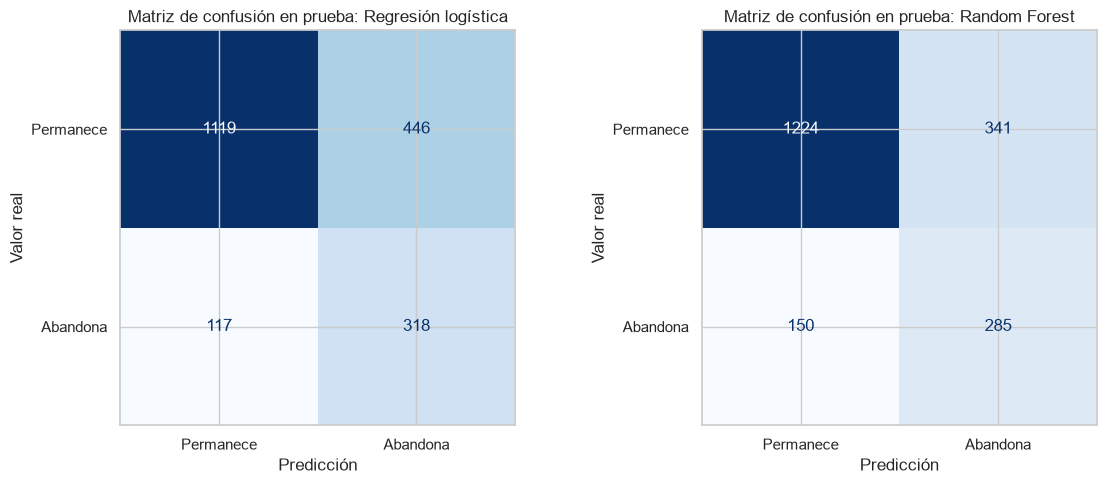


Reporte de clasificación en prueba del modelo seleccionado:
              precision    recall  f1-score   support

   Permanece     0.9053    0.7150    0.7990      1565
    Abandona     0.4162    0.7310    0.5304       435

    accuracy                         0.7185      2000
   macro avg     0.6608    0.7230    0.6647      2000
weighted avg     0.7990    0.7185    0.7406      2000



In [7]:
# La validación interna decide el algoritmo; la prueba externa permanece intacta.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
print(f"Ajuste interno: {len(X_fit):,} filas | Validación: {len(X_val):,} filas | Prueba reservada: {len(X_test):,} filas")

validation_rows = []
for name, pipeline in models.items():
    candidate = clone(pipeline)
    candidate.fit(X_fit, y_fit)
    val_pred = candidate.predict(X_val)
    validation_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0),
    })

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["F1", "Recall"], ascending=False
).reset_index(drop=True)
print("Comparación en validación (base de la selección):")
display(validation_results.round(4))

F1_TOLERANCE = 0.01
best_validation_f1 = validation_results["F1"].max()
eligible_models = validation_results[
    validation_results["F1"] >= best_validation_f1 - F1_TOLERANCE
]
recommended_model = eligible_models.sort_values(
    ["Recall", "F1"], ascending=False
).iloc[0]["Modelo"]
print(f"Modelo seleccionado en validación por la regla F1-Recall: {recommended_model}")

# Se reajustan ambos candidatos con las 6,000 filas de entrenamiento y se informa
# su desempeño en las mismas 2,000 filas de prueba, sin cambiar la selección.
results = []
predictions = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    train_pred = pipeline.predict(X_train)
    predictions[name] = y_pred
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "F1 entrenamiento": f1_score(y_train, train_pred, zero_division=0),
    })

model_results = pd.DataFrame(results).sort_values(
    ["F1", "Recall"], ascending=False
).reset_index(drop=True)
print("Evaluación final en la prueba reservada (no interviene en la selección):")
display(model_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], labels=[0, 1],
        display_labels=["Permanece", "Abandona"], ax=ax, colorbar=False, cmap="Blues",
    )
    ax.set_title(f"Matriz de confusión en prueba: {name}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación en prueba del modelo seleccionado:")
print(classification_report(
    y_test, predictions[recommended_model], digits=4, zero_division=0,
    target_names=["Permanece", "Abandona"],
))


## 6. Límites y riesgos técnicos

**Sobreajuste y subajuste.** La diferencia entre el F1 calculado en entrenamiento y en prueba es una señal de generalización, no un diagnóstico definitivo. Se comparan ambas brechas abajo. Una brecha amplia puede indicar sobreajuste; valores modestos en ambos conjuntos indican desempeño limitado, pero **no prueban subajuste** sin contrastar una línea base, curvas de aprendizaje y otros ajustes del modelo.

**Valores atípicos.** El rango intercuartílico se calcula exclusivamente con las 6,000 filas de entrenamiento. Se vuelve a entrenar el modelo seleccionado sin las filas marcadas y se compara en las mismas 2,000 filas de prueba. Es un análisis de sensibilidad descriptivo: no cambia el modelo elegido en validación ni usa la prueba para optimizarlo. Un valor extremo de llamadas de soporte o gasto podría ser un cliente válido y de alto riesgo; eliminarlo automáticamente puede perder información útil.

**Sesgos e interpretabilidad.** Edad y género no entran en el modelo, pero otras variables podrían actuar como sustitutos de atributos sensibles en datos reales. La auditoría de la sección 7 es exploratoria y sintética; no certifica ausencia de discriminación. La Regresión Logística seleccionada es más fácil de explicar que Random Forest, pero sus coeficientes describen asociaciones en variables transformadas, no causas. Además, `class_weight="balanced"` puede alterar la calibración de las probabilidades; no deben presentarse como riesgos individuales verificados sin comprobar esa calibración.

**Representatividad e impacto operativo.** La etiqueta y los clientes son simulados. Si los datos reales difieren de este escenario, podrían aumentar los contactos innecesarios y los abandonos omitidos; las métricas de prueba sintética dejarían de anticipar la carga de trabajo o el beneficio de una campaña. Esto debe comprobarse con historial real antes de cualquier uso operativo.


In [8]:
q1 = X_train[numeric_features].quantile(0.25)
q3 = X_train[numeric_features].quantile(0.75)
iqr = q3 - q1
outlier_summary = pd.DataFrame({
    "variable": numeric_features,
    "atípicos": [
        int(((X_train[column] < q1[column] - 1.5 * iqr[column]) |
             (X_train[column] > q3[column] + 1.5 * iqr[column])).sum())
        for column in numeric_features
    ],
})
outlier_summary["porcentaje"] = outlier_summary["atípicos"] / len(X_train)
display(outlier_summary.round({"porcentaje": 4}))

generalization_gap = model_results[["Modelo", "F1 entrenamiento", "F1"]].copy()
generalization_gap["brecha F1"] = generalization_gap["F1 entrenamiento"] - generalization_gap["F1"]
display(generalization_gap.round(4))


# Sensibilidad a valores atípicos: eliminación en entrenamiento únicamente.
outlier_mask = pd.Series(False, index=X_train.index)
for column in numeric_features:
    outlier_mask |= (X_train[column] < q1[column] - 1.5 * iqr[column]) | (
        X_train[column] > q3[column] + 1.5 * iqr[column]
    )

trimmed_model = clone(models[recommended_model])
trimmed_model.fit(X_train.loc[~outlier_mask], y_train.loc[~outlier_mask])
trimmed_predictions = trimmed_model.predict(X_test)
outlier_effect = pd.DataFrame({
    "escenario": ["Original", "Sin atípicos en entrenamiento"],
    "filas entrenamiento": [len(X_train), int((~outlier_mask).sum())],
    "Accuracy prueba": [
        accuracy_score(y_test, predictions[recommended_model]),
        accuracy_score(y_test, trimmed_predictions),
    ],
    "Recall prueba": [
        recall_score(y_test, predictions[recommended_model]),
        recall_score(y_test, trimmed_predictions),
    ],
    "F1 prueba": [
        f1_score(y_test, predictions[recommended_model]),
        f1_score(y_test, trimmed_predictions),
    ],
})
print(f"Sensibilidad a valores atípicos: se identificaron {outlier_mask.sum()} filas de entrenamiento.")
display(outlier_effect.round(4))


forest_gap = generalization_gap.loc[
    generalization_gap["Modelo"] == "Random Forest", "brecha F1"
].iloc[0]
logistic_gap = generalization_gap.loc[
    generalization_gap["Modelo"] == "Regresión logística", "brecha F1"
].iloc[0]
f1_original = outlier_effect.loc[0, "F1 prueba"]
f1_trimmed = outlier_effect.loc[1, "F1 prueba"]
recall_original = outlier_effect.loc[0, "Recall prueba"]
recall_trimmed = outlier_effect.loc[1, "Recall prueba"]

display(Markdown(f"""
**Lectura de riesgos.** Random Forest presenta una brecha F1 entrenamiento-prueba de **{forest_gap:.4f}**, compatible con posible sobreajuste; la de Regresión Logística es **{logistic_gap:.4f}**, sin una señal comparable. El F1 cercano a 0.53 del modelo recomendado en ambos conjuntos muestra capacidad predictiva limitada en esta simulación, pero no basta para afirmar subajuste.

El filtro IQR marcó **{outlier_mask.sum()} de {len(X_train):,} filas** de entrenamiento (**{outlier_mask.mean():.2%}**). Al quitarlas, el F1 de prueba cambió de **{f1_original:.4f}** a **{f1_trimmed:.4f}** ({f1_trimmed - f1_original:+.4f}), mientras Recall pasó de **{recall_original:.4f}** a **{recall_trimmed:.4f}**. No hubo mejora de F1; por ello no se recomienda eliminar atípicos automáticamente. Estas diferencias describen solo el escenario sintético y no justifican modificar la selección del modelo.
"""))


,variable,atípicos,porcentaje
0,tenure,0,0.0000
1,usage_frequency,0,0.0000
2,support_calls,87,0.0145
3,payment_delay,0,0.0000
4,total_spend,7,0.0012
5,last_interaction,0,0.0000


,Modelo,F1 entrenamiento,F1,brecha F1
0,Random Forest,0.7775,0.5372,0.2402
1,Regresión logística,0.5396,0.5304,0.0092


Sensibilidad a valores atípicos: se identificaron 94 filas de entrenamiento.


,escenario,filas entrenamiento,Accuracy prueba,Recall prueba,F1 prueba
0,Original,6000,0.7185,0.7310,0.5304
1,Sin atípicos en entrenamiento,5906,0.7105,0.7425,0.5273



**Lectura de riesgos.** Random Forest presenta una brecha F1 entrenamiento-prueba de **0.2402**, compatible con posible sobreajuste; la de Regresión Logística es **0.0092**, sin una señal comparable. El F1 cercano a 0.53 del modelo recomendado en ambos conjuntos muestra capacidad predictiva limitada en esta simulación, pero no basta para afirmar subajuste.

El filtro IQR marcó **94 de 6,000 filas** de entrenamiento (**1.57%**). Al quitarlas, el F1 de prueba cambió de **0.5304** a **0.5273** (-0.0031), mientras Recall pasó de **0.7310** a **0.7425**. No hubo mejora de F1; por ello no se recomienda eliminar atípicos automáticamente. Estas diferencias describen solo el escenario sintético y no justifican modificar la selección del modelo.


## 7. Consideraciones éticas, privacidad y transparencia

**Alcance de la auditoría.** El modelo no usa `age` ni `gender`; se examinan **solo edad y género** por grupos en las 2,000 filas de prueba sintética. `language` y `pet` no se usan para entrenar **ni se auditan** porque no tienen una justificación en este caso. La exclusión de atributos sensibles no elimina el riesgo de variables sustitutas, y las diferencias descriptivas de esta simulación no prueban ni descartan discriminación sistemática. Antes de operar con clientes reales se necesitarían grupos pertinentes, datos representativos, tamaños suficientes, tasas de error por grupo y revisión de incertidumbre.

**Transparencia y supervisión.** Antes de un piloto, el equipo entregaría a los responsables una ficha del modelo con finalidad, procedencia y periodo de los datos, variables y exclusiones, versión, umbral, métricas globales y por grupo, falsas alarmas, abandonos omitidos, limitaciones y fecha de revisión. Cada campaña registraría el criterio de contacto y permitiría revisión humana y corrección de datos o decisiones. Las puntuaciones no se presentarían como causalidad ni como probabilidades calibradas sin verificación.

**Privacidad y marco normativo de El Salvador.** Este notebook utiliza datos simulados, no expedientes reales. Para una empresa de suscripción que trate datos de clientes en El Salvador, la referencia principal es la [Ley para la Protección de Datos Personales, Decreto 144, publicada en el Diario Oficial el 15 de noviembre de 2024](https://www.diariooficial.gob.sv/seleccion/31396), cuyo ámbito incluye a entidades privadas que tratan datos personales. La [Asamblea Legislativa informó reformas aprobadas el 17 de septiembre de 2026](https://www.asamblea.gob.sv/node/14116); antes de un piloto, el equipo jurídico debe verificar su publicación, vigencia y texto consolidado. El plan de cumplimiento documentaría finalidad y base jurídica para el tratamiento, información y mecanismos para ejercer derechos de los titulares, minimización, control de acceso, seguridad y plazo de conservación/eliminación. También se revisarían las reglas aplicables a comunicaciones comerciales y trato no discriminatorio. **Esta identificación normativa no equivale a certificar cumplimiento**: no se utilizarán datos ni decisiones sobre personas reales sin la revisión jurídica y técnica correspondiente.


In [9]:
# Auditoría exploratoria de edad y género: grupos no usados como predictores.
audit = churn_df.loc[X_test.index, ["gender", "age", "Churn"]].copy()
audit["grupo_edad"] = pd.cut(
    audit["age"], bins=[17, 29, 44, 59, 80], labels=["18-29", "30-44", "45-59", "60+"]
)
audit["predicción"] = predictions[recommended_model]

def group_metrics(frame, group_column):
    rows = []
    for group, data in frame.groupby(group_column, observed=True):
        positives = int(data["Churn"].sum())
        negatives = len(data) - positives
        detected = int(((data["Churn"] == 1) & (data["predicción"] == 1)).sum())
        false_positives = int(((data["Churn"] == 0) & (data["predicción"] == 1)).sum())
        rows.append({
            "grupo": group,
            "n": len(data),
            "positivos reales": positives,
            "tasa real": data["Churn"].mean(),
            "tasa predicha positiva": data["predicción"].mean(),
            "recall": detected / positives if positives else np.nan,
            "tasa de falsos positivos": false_positives / negatives if negatives else np.nan,
        })
    return pd.DataFrame(rows)

gender_audit = group_metrics(audit, "gender")
age_audit = group_metrics(audit, "grupo_edad")
print("Auditoría exploratoria por género (datos sintéticos):")
display(gender_audit.round(4))
print("Auditoría exploratoria por edad (datos sintéticos):")
display(age_audit.round(4))

highest_age_recall = age_audit.loc[age_audit["recall"].idxmax()]
lowest_age_recall = age_audit.loc[age_audit["recall"].idxmin()]
small_gender_group = gender_audit.loc[gender_audit["n"].idxmin()]
small_age_group = age_audit.loc[age_audit["n"].idxmin()]
display(Markdown(f"""
**Interpretación cautelosa.** El Recall por edad va de **{lowest_age_recall['recall']:.1%}** en {lowest_age_recall['grupo']} a **{highest_age_recall['recall']:.1%}** en {highest_age_recall['grupo']} (diferencia de **{(highest_age_recall['recall'] - lowest_age_recall['recall']) * 100:.1f} puntos porcentuales**). La tabla también muestra la tasa de falsos positivos, es decir, contactos dirigidos a quienes no abandonarían. El grupo de género con menos observaciones tiene **{small_gender_group['n']}** personas y **{small_gender_group['positivos reales']}** abandonos; el grupo de edad más pequeño tiene **{small_age_group['n']}** personas y **{small_age_group['positivos reales']}** abandonos. Con estos tamaños y etiquetas sintéticas no se puede atribuir la diferencia a discriminación ni asegurar ausencia de sesgo. Una auditoría real requeriría intervalos de incertidumbre y seguimiento de errores por grupo.
"""))


Auditoría exploratoria por género (datos sintéticos):


,grupo,n,positivos reales,tasa real,tasa predicha positiva,recall,tasa de falsos positivos
0,Female,944,203,0.2150,0.3898,0.7192,0.2996
1,Male,988,221,0.2237,0.3735,0.7421,0.2673
2,Non-binary,68,11,0.1618,0.3971,0.7273,0.3333


Auditoría exploratoria por edad (datos sintéticos):


,grupo,n,positivos reales,tasa real,tasa predicha positiva,recall,tasa de falsos positivos
0,18-29,334,73,0.2186,0.4222,0.8630,0.2989
1,30-44,993,202,0.2034,0.3746,0.7178,0.2870
2,45-59,593,140,0.2361,0.3744,0.6786,0.2804
3,60+,80,20,0.2500,0.3625,0.7500,0.2333



**Interpretación cautelosa.** El Recall por edad va de **67.9%** en 45-59 a **86.3%** en 18-29 (diferencia de **18.4 puntos porcentuales**). La tabla también muestra la tasa de falsos positivos, es decir, contactos dirigidos a quienes no abandonarían. El grupo de género con menos observaciones tiene **68** personas y **11** abandonos; el grupo de edad más pequeño tiene **80** personas y **20** abandonos. Con estos tamaños y etiquetas sintéticas no se puede atribuir la diferencia a discriminación ni asegurar ausencia de sesgo. Una auditoría real requeriría intervalos de incertidumbre y seguimiento de errores por grupo.


## 8. Conclusión y recomendación final

La selección se decide con la regla F1-Recall declarada previamente y aplicada **solo a la validación interna**. La prueba reservada sirve para informar el desempeño y el costo operativo aproximado en este escenario, no para cambiar el ganador. La recomendación debe vincular explícitamente abandonos detectados con falsas alarmas: un mayor Recall puede requerir más contactos de retención. Sin costos de contacto y pérdida de clientes no se puede afirmar que un modelo maximice el beneficio económico.

La recomendación es **didáctica para datos sintéticos, no autorización de uso en producción**. Los pasos para un piloto son: obtener etiquetas reales y datos representativos, completar la revisión legal y de privacidad en El Salvador, fijar presupuesto y costos, ajustar el umbral usando validación, comprobar calibración y desempeño por grupos, evaluar en una muestra independiente y monitorear errores y cambios de población.


In [10]:
winner = model_results.loc[model_results["Modelo"] == recommended_model].iloc[0]
other = model_results.loc[model_results["Modelo"] != recommended_model].iloc[0]
validation_winner = validation_results.loc[validation_results["Modelo"] == recommended_model].iloc[0]
validation_other = validation_results.loc[validation_results["Modelo"] != recommended_model].iloc[0]
tn, fp, fn, tp = confusion_matrix(y_test, predictions[recommended_model], labels=[0, 1]).ravel()
other_tn, other_fp, other_fn, other_tp = confusion_matrix(
    y_test, predictions[other["Modelo"]], labels=[0, 1]
).ravel()

validation_f1_difference = validation_winner["F1"] - validation_other["F1"]
selection_detail = (
    f"La diferencia de F1 en validación fue {validation_f1_difference:.4f}, "
    f"superior a la tolerancia de {F1_TOLERANCE:.2f}; por tanto, el desempate por Recall no fue necesario."
    if validation_f1_difference > F1_TOLERANCE
    else f"Ambos modelos quedaron dentro de la tolerancia F1 de {F1_TOLERANCE:.2f}; decidió el mayor Recall."
)

display(Markdown(f"""
**Modelo recomendado para el ejercicio: {winner['Modelo']}.**

En validación obtuvo F1 = **{validation_winner['F1']:.4f}** y Recall = **{validation_winner['Recall']:.4f}**, frente a F1 = **{validation_other['F1']:.4f}** y Recall = **{validation_other['Recall']:.4f}** de {other['Modelo']}. {selection_detail} **La prueba no decidió la elección.**

En la prueba sintética, el recomendado obtuvo Accuracy = **{winner['Accuracy']:.4f}**, Precision = **{winner['Precision']:.4f}**, Recall = **{winner['Recall']:.4f}** y F1 = **{winner['F1']:.4f}**. {other['Modelo']} obtuvo F1 = **{other['F1']:.4f}** y Recall = **{other['Recall']:.4f}**. Su mayor F1 de prueba no reabre la selección realizada en validación. La brecha F1 entrenamiento-prueba fue **{winner['F1 entrenamiento'] - winner['F1']:.4f}** para el recomendado y **{other['F1 entrenamiento'] - other['F1']:.4f}** para el otro modelo.

De **{tp + fn}** abandonos simulados en prueba, el recomendado detectó **{tp}** y omitió **{fn}**, con **{fp}** falsas alarmas. Frente a {other['Modelo']}, detectó **{tp - other_tp:+d} abandonos** y produjo **{fp - other_fp:+d} falsas alarmas** en las mismas 2,000 personas simuladas. Esto expresa el intercambio estratégico: detectar más posibles abandonos consume más capacidad de contacto. Sin costo por intervención, valor de un abandono evitado ni eficacia de la campaña, **no se puede afirmar un beneficio económico neto**. Quitar atípicos cambió el F1 de **{outlier_effect.loc[0, 'F1 prueba']:.4f}** a **{outlier_effect.loc[1, 'F1 prueba']:.4f}**, por lo que no se recomienda hacerlo automáticamente.

**Recomendación y siguientes pasos.** Conservar este modelo como referencia didáctica, no aplicarlo a clientes reales todavía. Obtener historial etiquetado y representativo; verificar la versión vigente de la normativa salvadoreña, la base jurídica, el presupuesto y los costos; ajustar el umbral en validación; evaluar calibración, errores por grupo y desempeño en una prueba independiente; ejecutar un piloto con revisión humana y monitorear cambios, reclamaciones y sesgos antes de ampliar su uso.
"""))

checklist = pd.DataFrame({
    "Componente del análisis": [
        "Problema, variable objetivo y decisión estratégica",
        "Mapa y justificación de dos algoritmos",
        "Dataset sintético",
        "EDA y visualizaciones",
        "Verificación de supuesto técnico",
        "train_test_split y métricas de clasificación",
        "Riesgos, efecto de atípicos, ética, privacidad y recomendación",
    ],
    "Evidencia en este notebook": [
        "Secciones 1 y 2", "Sección 4", f"{len(churn_df):,} registros sintéticos",
        "Sección 3", "VIF en sección 4", "Sección 5", "Secciones 6 a 8",
    ],
})
display(checklist)



**Modelo recomendado para el ejercicio: Regresión logística.**

En validación obtuvo F1 = **0.5236** y Recall = **0.7011**, frente a F1 = **0.5078** y Recall = **0.6207** de Random Forest. La diferencia de F1 en validación fue 0.0158, superior a la tolerancia de 0.01; por tanto, el desempate por Recall no fue necesario. **La prueba no decidió la elección.**

En la prueba sintética, el recomendado obtuvo Accuracy = **0.7185**, Precision = **0.4162**, Recall = **0.7310** y F1 = **0.5304**. Random Forest obtuvo F1 = **0.5372** y Recall = **0.6552**. Su mayor F1 de prueba no reabre la selección realizada en validación. La brecha F1 entrenamiento-prueba fue **0.0092** para el recomendado y **0.2402** para el otro modelo.

De **435** abandonos simulados en prueba, el recomendado detectó **318** y omitió **117**, con **446** falsas alarmas. Frente a Random Forest, detectó **+33 abandonos** y produjo **+105 falsas alarmas** en las mismas 2,000 personas simuladas. Esto expresa el intercambio estratégico: detectar más posibles abandonos consume más capacidad de contacto. Sin costo por intervención, valor de un abandono evitado ni eficacia de la campaña, **no se puede afirmar un beneficio económico neto**. Quitar atípicos cambió el F1 de **0.5304** a **0.5273**, por lo que no se recomienda hacerlo automáticamente.

**Recomendación y siguientes pasos.** Conservar este modelo como referencia didáctica, no aplicarlo a clientes reales todavía. Obtener historial etiquetado y representativo; verificar la versión vigente de la normativa salvadoreña, la base jurídica, el presupuesto y los costos; ajustar el umbral en validación; evaluar calibración, errores por grupo y desempeño en una prueba independiente; ejecutar un piloto con revisión humana y monitorear cambios, reclamaciones y sesgos antes de ampliar su uso.


,Componente del análisis,Evidencia en este notebook
0,"Problema, variable objetivo y decisión estraté...",Secciones 1 y 2
1,Mapa y justificación de dos algoritmos,Sección 4
2,Dataset sintético,"8,000 registros sintéticos"
3,EDA y visualizaciones,Sección 3
4,Verificación de supuesto técnico,VIF en sección 4
5,train_test_split y métricas de clasificación,Sección 5
6,"Riesgos, efecto de atípicos, ética, privacidad...",Secciones 6 a 8
